# A/B-тестирование новой формы оплаты ЖКХ

## 1. Бизнес-контекст

Существующая форма оплаты ЖКХ требовала от пользователей самостоятельно
вводить платёжные данные.

Была разработана новая версия формы с автозаполнением, цель которой —
снизить количество действий со стороны пользователя и повысить конверсию
в успешную оплату.

### Продуктовый вопрос

Увеличивает ли новая форма оплаты конверсию пользователей
от открытия формы до успешного завершения платежа?


In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from statsmodels.stats.proportion import proportions_ztest, confint_proportions_2indep

In [2]:
file_path = '../data/data.xlsx'
pd.ExcelFile(file_path).sheet_names

['Пользователи', 'Платежи']

## 2. Гипотеза и дизайн эксперимента

### Продуктовая гипотеза

Новая форма оплаты ЖКХ с автозаполнением увеличит конверсию пользователей
от открытия формы до успешного завершения платежа.

### Дизайн эксперимента

- **Период проведения:** 1–30 апреля 2024 года
- **Контрольная группа (A):** текущая форма оплаты
- **Тестовая группа (B):** новая форма оплаты с автозаполнением
- **Основная метрика:** конверсия от открытия формы до успешной оплаты
- **Уровень значимости:** α = 0,05

### Воронка


Открытие формы  -> Ввод данных
-> Подтверждение 
-> Успешная оплата

## 3. Подготовка данных

Для анализа использовались два набора данных:

* **Users** — информация о пользователях и их принадлежности к экспериментальной группе;
* **Payments** — информация о платежах и этапах прохождения платежной воронки.

### 3.1. Загрузка данных

Загрузим данные пользователей и платежей для дальнейшего анализа.


In [3]:
users = pd.read_excel(file_path, sheet_name='Пользователи')
users.shape

(1504, 5)

In [4]:
users.head()

,user_id,group,age,city,device_type
0,1001,A,31,Москва,ios
1,1002,A,31,Москва,ios
2,1003,A,25,Москва,android
3,1004,A,20,Москва,ios
4,1005,A,34,Москва,ios


### 3.2. Проверка качества данных

Перед проведением анализа проверим данные на наличие:

* пропущенных значений;
* выбросов;
* дубликатов;
* платежей без соответствующего пользователя;
* некорректного распределения пользователей по экспериментальным группам.


In [5]:
users.info()

<class 'pandas.DataFrame'>
RangeIndex: 1504 entries, 0 to 1503
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   user_id      1504 non-null   int64
 1   group        1503 non-null   str  
 2   age          1504 non-null   int64
 3   city         1503 non-null   str  
 4   device_type  1504 non-null   str  
dtypes: int64(2), str(3)
memory usage: 58.9 KB


Видим что числовых у нас два столбца: id и возраст. Проверим возраст на выбросы

In [6]:
users['age'].describe()

count    1504.000000
mean       32.745346
std         8.410915
min        -5.000000
25%        27.000000
50%        33.000000
75%        38.000000
max       150.000000
Name: age, dtype: float64

In [7]:
users['age'].value_counts().sort_index().head(5)

age
-5      1
 20    98
 21    36
 22    35
 23    43
Name: count, dtype: int64

In [8]:
users['age'].value_counts().sort_index().tail(5)

age
56     1
57     1
58     1
60     2
150    1
Name: count, dtype: int64

Выбросов по возрасту всего два. Их удаление не повлияет на весь дата фрейм

In [9]:
users_clean = users[(users['age'] >= 18) & (users['age'] <= 100)].copy()
# проверка после удаления
users_clean.shape

(1502, 5)

В столбцах group и city есть пропущенные значения,возможно это одна или две строки

In [10]:
users_clean[users_clean['group'].isna() | users_clean['city'].isna()]

,user_id,group,age,city,device_type
1500,9001,NaN,25,Москва,ios
1503,9004,A,30,NaN,android


Это две строки, но их удаление также не влияет на весь дата фрейм

In [11]:
users_clean = users_clean.dropna(subset=['group', 'city']).copy()
users_clean.shape

(1500, 5)

Проверим наполение city и device_type на опечатки

In [12]:
print(users_clean['city'].value_counts())
print(users_clean['device_type'].value_counts())

city
Москва    594
Регион    513
СПб       393
Name: count, dtype: int64
device_type
android    775
ios        725
Name: count, dtype: int64


Опечаток нет

Запишем user_id удаленные из Пользователей

In [13]:
bad_users = users[
    (users['age'] < 18) |
    (users['age'] > 100) |
    (users['group'].isna()) |
    (users['city'].isna())
]['user_id']

bad_users

1500    9001
1501    9002
1502    9003
1503    9004
Name: user_id, dtype: int64

# Работаем со страницей Платежи

In [14]:
payments = pd.read_excel(file_path, sheet_name='Платежи')
payments.shape

(2661, 7)

In [15]:
payments.head()

,payment_id,user_id,group,step1_opened,step2_entered,step3_confirmed,step4_success
0,5001,1001.0,A,2024-04-16 06:06:00,2024-04-16 06:10:00,NaT,NaT
1,5002,1002.0,A,2024-04-12 07:38:00,2024-04-12 07:41:00,NaT,NaT
2,5003,1003.0,A,2024-04-26 20:03:00,2024-04-26 20:07:00,NaT,NaT
3,5004,1004.0,A,2024-04-09 16:02:00,NaT,NaT,NaT
4,5005,1004.0,A,2024-04-04 03:46:00,2024-04-04 03:54:00,2024-04-04 03:57:00,2024-04-04 04:02:00


In [16]:
payments.info()

<class 'pandas.DataFrame'>
RangeIndex: 2661 entries, 0 to 2660
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   payment_id       2661 non-null   int64         
 1   user_id          2660 non-null   float64       
 2   group            2661 non-null   str           
 3   step1_opened     2661 non-null   datetime64[us]
 4   step2_entered    2256 non-null   datetime64[us]
 5   step3_confirmed  1719 non-null   datetime64[us]
 6   step4_success    1522 non-null   datetime64[us]
dtypes: datetime64[us](4), float64(1), int64(1), str(1)
memory usage: 145.7 KB


Проверим дубликаты записей и идентификаторов платежей

In [17]:
payments.duplicated().sum()

0

In [18]:
payments['payment_id'].duplicated().sum()

0

Проверим есть ли в записях пользователи, которых удалили

In [19]:
payments[payments['user_id'].isin(bad_users)]

,payment_id,user_id,group,step1_opened,step2_entered,step3_confirmed,step4_success
2657,7658,9004.0,A,2024-04-05 16:14:00,2024-04-05 16:15:00,2024-04-05 16:18:00,2024-04-05 16:23:00


Также из инфо было видно, что есть пользователь без id

In [20]:
payments[payments['user_id'].isna()]

,payment_id,user_id,group,step1_opened,step2_entered,step3_confirmed,step4_success
2660,99003,NaN,A,2024-04-12 09:15:00,NaT,NaT,NaT


In [21]:
users_clean

,user_id,group,age,city,device_type
0,1001,A,31,Москва,ios
1,1002,A,31,Москва,ios
2,1003,A,25,Москва,android
3,1004,A,20,Москва,ios
4,1005,A,34,Москва,ios
...,...,...,...,...,...
1495,2496,B,27,Москва,android
1496,2497,B,33,Москва,android
1497,2498,B,28,СПб,ios
1498,2499,B,42,Москва,ios


In [22]:
payments_clean = payments[
    payments['user_id'].notna() &
    payments['user_id'].isin(users_clean['user_id'])
].copy()

### 3.3. Формирование итогового датасета

Для дальнейшего анализа объединим данные о пользователях и их платежах.

При объединении источников принадлежность пользователя к экспериментальной группе определяется по данным из таблицы **Users**.

Поскольку один пользователь может совершить несколько платежей, дальнейший анализ конверсии проводится на **уровне пользователя**, а не отдельного платежа.


In [23]:
df = payments_clean.merge(
    users_clean,
    on='user_id',
    how='inner',
    suffixes=('_payment', '_user')
)
df.shape

(2659, 11)

In [24]:
df.head()

,payment_id,user_id,group_payment,step1_opened,step2_entered,step3_confirmed,step4_success,group_user,age,city,device_type
0,5001,1001.0,A,2024-04-16 06:06:00,2024-04-16 06:10:00,NaT,NaT,A,31,Москва,ios
1,5002,1002.0,A,2024-04-12 07:38:00,2024-04-12 07:41:00,NaT,NaT,A,31,Москва,ios
2,5003,1003.0,A,2024-04-26 20:03:00,2024-04-26 20:07:00,NaT,NaT,A,25,Москва,android
3,5004,1004.0,A,2024-04-09 16:02:00,NaT,NaT,NaT,A,20,Москва,ios
4,5005,1004.0,A,2024-04-04 03:46:00,2024-04-04 03:54:00,2024-04-04 03:57:00,2024-04-04 04:02:00,A,20,Москва,ios


После объединения появился клон столбца group: group_payment и group_user. Сделаем проверку совпадения групп

In [25]:
(df['group_payment'] != df['group_user']).sum()

1

In [26]:
df[df['group_payment'] != df['group_user']]

,payment_id,user_id,group_payment,step1_opened,step2_entered,step3_confirmed,step4_success,group_user,age,city,device_type
2658,99002,1010.0,B,2024-04-08 14:20:00,2024-04-08 14:23:00,2024-04-08 14:28:00,2024-04-08 14:29:00,A,26,Москва,android


Для A/B-теста логичнее считать правильной группу из таблицы «Пользователи», потому что эксперимент назначается пользователю, а не отдельному платежу.

In [27]:
# Сначала сохраним группу пользователя как основную
df['group'] = df['group_user']

In [28]:
# Удаляем дублирующие столбцы
df = df.drop(columns=['group_user', 'group_payment'])

## 4. Проверка экспериментальных групп

Перед сравнением конверсии проверим состав контрольной и тестовой групп.

Сравним группы по:

* количеству пользователей;
* городу;
* типу устройства;
* возрасту.


In [29]:
df['group'].value_counts()

group
B    1351
A    1308
Name: count, dtype: int64

Размеры контрольной и тестовой групп сопоставимы.

Проверим распределение платежей между контрольной и тестовой группами по городу, типу устройства и возрасту.

In [30]:
pd.crosstab(df['group'], df['city'])

city,Москва,Регион,СПб
group,,,
A,503,461,344
B,567,428,356


In [31]:
pd.crosstab(df['group'], df['device_type'])

device_type,android,ios
group,,
A,714,594
B,666,685


Распределение пользователей по городу и типу устройства сопоставимо между экспериментальными группами.

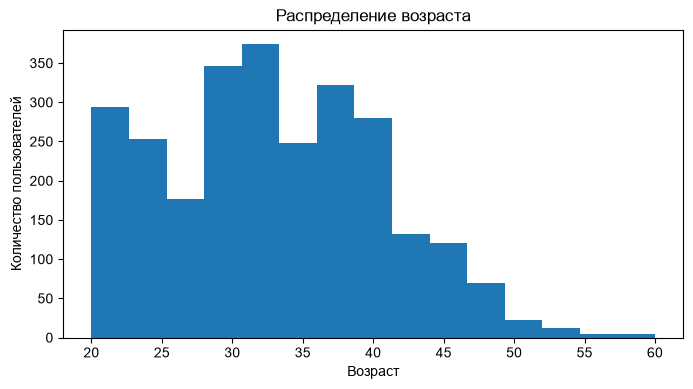

In [33]:
plt.figure(figsize=(8, 4))
plt.hist(df['age'], bins=15)
plt.title('Распределение возраста')
plt.xlabel('Возраст')
plt.ylabel('Количество пользователей')
plt.show()

## 5. Анализ воронки

Платёжный процесс состоит из последовательных этапов:

**Открытие формы → Ввод реквизитов → Подтверждение → Успешная оплата**

Поскольку эксперимент рандомизирован на уровне пользователей, основная метрика будет рассчитываться на уровне пользователя.

Сначала рассмотрим прохождение платежей по этапам воронки, затем агрегируем данные до уровня пользователя.

### 5.1. Воронка на уровне платежей

Сначала рассмотрим распределение платежей по этапам воронки.

Этот анализ используется для диагностики поведения платежей. Основная метрика A/B-теста далее рассчитывается на уровне пользователей.

In [34]:
funnel = {
    'Открыли форму': df['step1_opened'].notna().sum(),
    'Ввели реквизиты': df['step2_entered'].notna().sum(),
    'Подтвердили платёж': df['step3_confirmed'].notna().sum(),
    'Успешный платёж': df['step4_success'].notna().sum()
}

funnel

{'Открыли форму': 2659,
 'Ввели реквизиты': 2255,
 'Подтвердили платёж': 1718,
 'Успешный платёж': 1521}

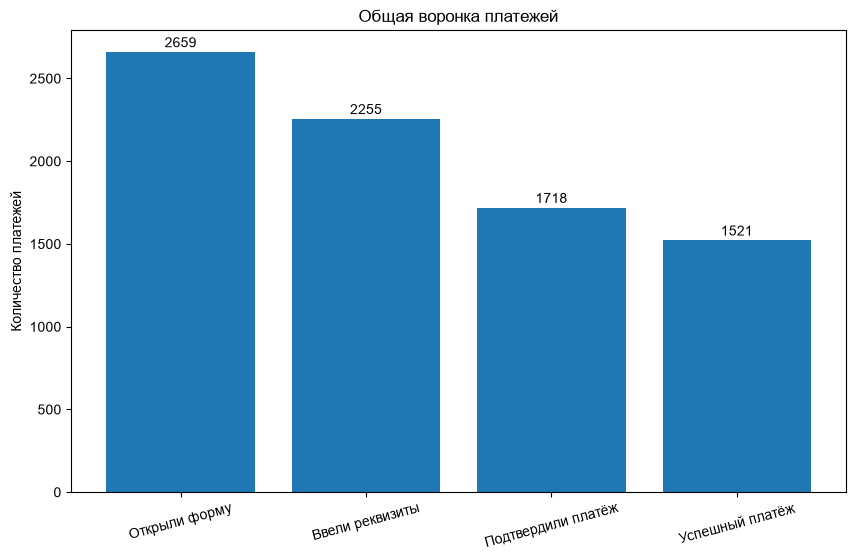

In [35]:
steps = list(funnel.keys())
values = list(funnel.values())

plt.figure(figsize=(10, 6))
plt.bar(steps, values)

plt.title('Общая воронка платежей')
plt.ylabel('Количество платежей')
plt.xticks(rotation=15)

for i, value in enumerate(values):
    plt.text(i, value + 30, str(value), ha='center')

plt.show()

### 5.2. Воронка платежей по группам

Сравним прохождение этапов воронки между контрольной и тестовой группами.

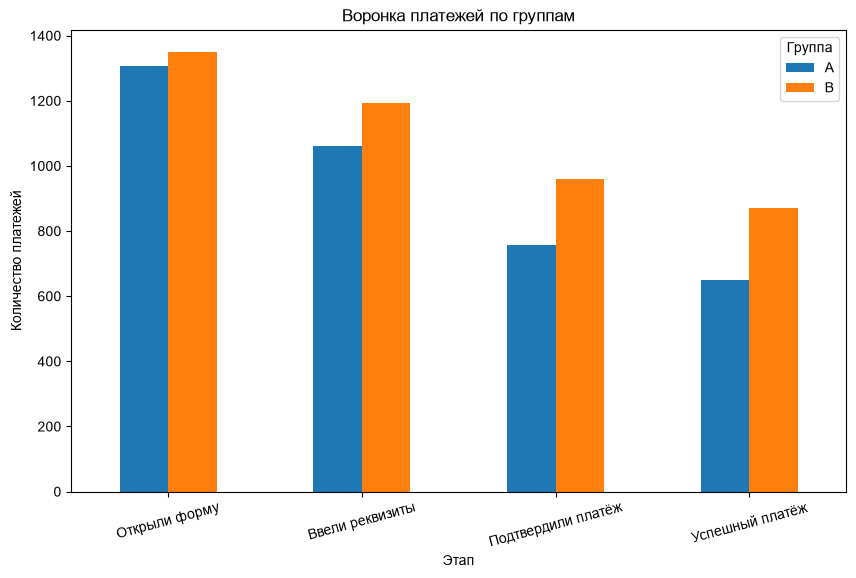

In [36]:
funnel_by_group = df.groupby('group').agg(
    opened=('step1_opened', 'count'),
    entered=('step2_entered', 'count'),
    confirmed=('step3_confirmed', 'count'),
    success=('step4_success', 'count')
)

funnel_by_group.columns = [
    'Открыли форму',
    'Ввели реквизиты',
    'Подтвердили платёж',
    'Успешный платёж'
]

funnel_by_group.T.plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('Воронка платежей по группам')
plt.xlabel('Этап')
plt.ylabel('Количество платежей')
plt.xticks(rotation=15)
plt.legend(title='Группа')

plt.show()

In [37]:
conversion = pd.DataFrame(index=funnel_by_group.index)

conversion['Открыли → Ввели'] = (
    funnel_by_group['Ввели реквизиты'].astype(str) + ' (' +
    (funnel_by_group['Ввели реквизиты'] / funnel_by_group['Открыли форму'] * 100).round(2).astype(str) + '%)'
)

conversion['Ввели → Подтвердили'] = (
    funnel_by_group['Подтвердили платёж'].astype(str) + ' (' +
    (funnel_by_group['Подтвердили платёж'] / funnel_by_group['Ввели реквизиты'] * 100).round(2).astype(str) + '%)'
)

conversion['Подтвердили → Успех'] = (
    funnel_by_group['Успешный платёж'].astype(str) + ' (' +
    (funnel_by_group['Успешный платёж'] / funnel_by_group['Подтвердили платёж'] * 100).round(2).astype(str) + '%)'
)

conversion['Общая конверсия'] = (
    funnel_by_group['Успешный платёж'].astype(str) + ' (' +
    (funnel_by_group['Успешный платёж'] / funnel_by_group['Открыли форму'] * 100).round(2).astype(str) + '%)'
)

conversion

,Открыли → Ввели,Ввели → Подтвердили,Подтвердили → Успех,Общая конверсия
group,,,,
A,1061 (81.12%),758 (71.44%),651 (85.88%),651 (49.77%)
B,1194 (88.38%),960 (80.4%),870 (90.62%),870 (64.4%)


## 6. Анализ на уровне пользователей

Эксперимент рандомизирован на уровне пользователей, поэтому основная метрика должна рассчитываться на уровне пользователя, а не отдельного платежа.

В исходном датасете один пользователь может совершить несколько платежей. Если считать каждую строку как отдельное наблюдение, пользователи с большим количеством платежей получат больший вес в анализе.

Поэтому агрегируем историю платежей каждого пользователя в одну строку.

Пользователь считается сконвертировавшимся, если хотя бы один его платёж достиг этапа «Успешная оплата».

In [38]:
user_funnel = df.groupby('user_id').agg(
    group=('group', 'first'),
    opened=('step1_opened', 'count'),
    entered=('step2_entered', 'count'),
    confirmed=('step3_confirmed', 'count'),
    success=('step4_success', 'count')
)

user_funnel.columns = ['Группа', 'Открыли форму', 'Ввели реквизиты', 'Подтвердили платёж', 'Успешный платёж']

user_funnel['Открыли форму'] = user_funnel['Открыли форму'] > 0
user_funnel['Ввели реквизиты'] = user_funnel['Ввели реквизиты'] > 0
user_funnel['Подтвердили платёж'] = user_funnel['Подтвердили платёж'] > 0
user_funnel['Успешный платёж'] = user_funnel['Успешный платёж'] > 0

user_funnel.head()

,Группа,Открыли форму,Ввели реквизиты,Подтвердили платёж,Успешный платёж
user_id,,,,,
1001.0,A,True,True,False,False
1002.0,A,True,True,False,False
1003.0,A,True,True,False,False
1004.0,A,True,True,True,True
1005.0,A,True,True,True,True


In [39]:
user_funnel_counts = user_funnel.groupby('Группа')[
    ['Открыли форму', 'Ввели реквизиты', 'Подтвердили платёж', 'Успешный платёж']
].sum()

funnel_result = pd.DataFrame(index=user_funnel_counts.index)

funnel_result['Открыли → Ввели'] = (
    user_funnel_counts['Ввели реквизиты'].astype(str) + ' (' +
    (user_funnel_counts['Ввели реквизиты'] / user_funnel_counts['Открыли форму'] * 100).round(1).astype(str) + '%)'
)

funnel_result['Ввели → Подтвердили'] = (
    user_funnel_counts['Подтвердили платёж'].astype(str) + ' (' +
    (user_funnel_counts['Подтвердили платёж'] / user_funnel_counts['Ввели реквизиты'] * 100).round(1).astype(str) + '%)'
)

funnel_result['Подтвердили → Успех'] = (
    user_funnel_counts['Успешный платёж'].astype(str) + ' (' +
    (user_funnel_counts['Успешный платёж'] / user_funnel_counts['Подтвердили платёж'] * 100).round(1).astype(str) + '%)'
)

funnel_result['Общая конверсия'] = (
    user_funnel_counts['Успешный платёж'].astype(str) + ' (' +
    (user_funnel_counts['Успешный платёж'] / user_funnel_counts['Открыли форму'] * 100).round(1).astype(str) + '%)'
)


funnel_result.head()

,Открыли → Ввели,Ввели → Подтвердили,Подтвердили → Успех,Общая конверсия
Группа,,,,
A,671 (89.5%),548 (81.7%),493 (90.0%),493 (65.7%)
B,707 (94.3%),644 (91.1%),603 (93.6%),603 (80.4%)


In [40]:
tt_font = None
for f in fm.findSystemFonts():
    if 'TT Norms Pro' in f or 'TTNormsPro' in f:
        tt_font = f
        break
if tt_font:
    plt.rcParams['font.family'] = 'TT Norms Pro'
else:
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['Inter', 'Arial', 'DejaVu Sans']

colors = ['#6C5CE7', '#00B894', '#FDCB6E', '#E17055']


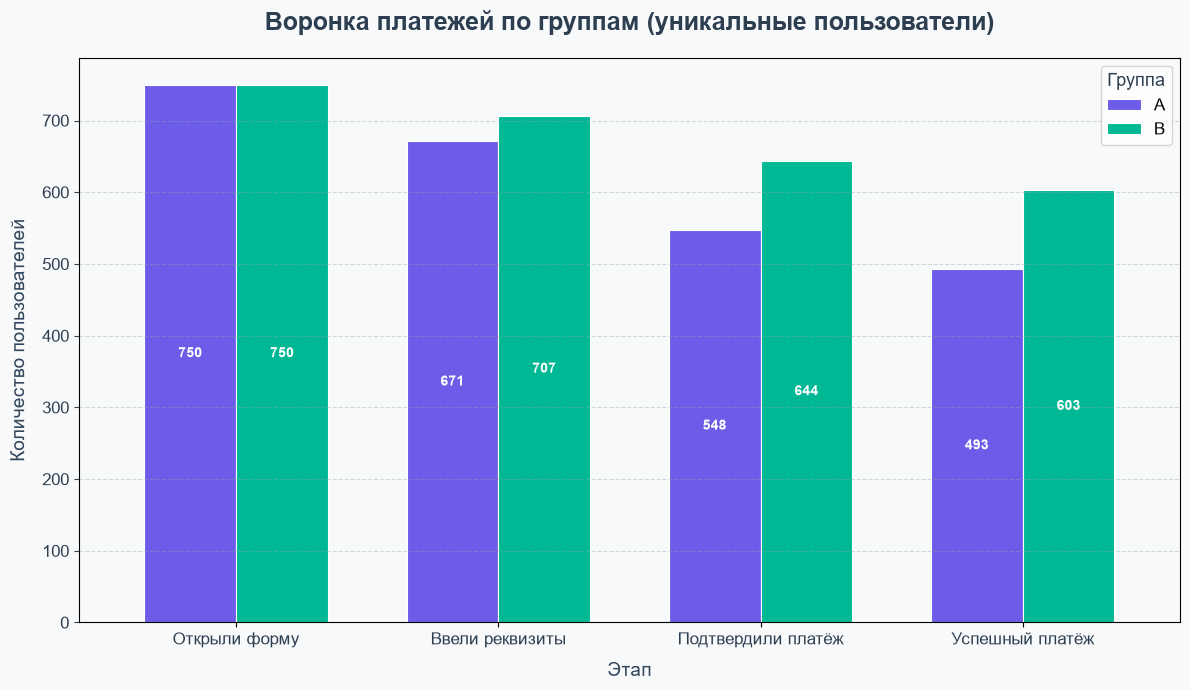

In [41]:
ax = user_funnel_counts.T.plot(
    kind='bar',
    figsize=(12, 7),
    color=colors[:len(user_funnel_counts)],
    edgecolor='white',
    linewidth=0.8,
    width=0.7,
    rot=0
)

ax.set_facecolor('#f8f9fa')
fig = ax.get_figure()
fig.patch.set_facecolor('#f8f9fa')

ax.set_title('Воронка платежей по группам (уникальные пользователи)',
             fontsize=18, fontweight='bold', pad=20, color='#2c3e50')
ax.set_xlabel('Этап', fontsize=14, labelpad=10, color='#34495e')
ax.set_ylabel('Количество пользователей', fontsize=14, labelpad=10, color='#34495e')

ax.set_xticklabels(ax.get_xticklabels(), ha='center', fontsize=12, color='#2c3e50')
ax.tick_params(axis='y', labelsize=12, colors='#2c3e50')

ax.yaxis.grid(True, linestyle='--', alpha=0.4, color='#95a5a6')
ax.xaxis.grid(False)

legend = ax.legend(
    title='Группа',
    frameon=True,
    fontsize=12,
    title_fontsize=13,
    loc='upper right'

)
legend.get_title().set_color('#2c3e50')

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%d',
        label_type='center',
        color='white',
        fontsize=10,
        fontweight='bold',
        padding=0
    )

plt.tight_layout()
plt.show()

## 7. Проверка статистической значимости

Основная метрика — конверсия из открытия формы в успешный платёж.

Гипотезы:

- **H₀:** конверсия в группе B не выше конверсии в группе A: $p_B \leq p_A$
- **H₁:** конверсия в группе B выше конверсии в группе A: $p_B > p_A$

Для проверки используем **односторонний z-тест для сравнения двух пропорций**.

Уровень значимости: $\alpha = 0.05$.

In [42]:
success = user_funnel_counts['Успешный платёж'].values
nobs = user_funnel_counts['Открыли форму'].values

stat, p_value = proportions_ztest(
    success,
    nobs,
    alternative='smaller'
)

print("z-statistic:", stat)
print("p-value:", p_value)

z-statistic: -6.402393383329898
p-value: 7.64799693332123e-11


### Вывод

Полученное значение p-value значительно меньше уровня значимости $\alpha = 0.05$.

Следовательно, отвергаем нулевую гипотезу $H_0$.

Таким образом, наблюдаем статистически значимое различие конверсии между группами в пользу новой формы оплаты.

## 8. Размер эффекта

Помимо статистической значимости, оценим величину изменения основной метрики.

Рассчитаем:

- конверсию в каждой экспериментальной группе;
- абсолютный прирост в процентных пунктах;
- относительный прирост конверсии.

In [43]:
conversion_a = (
    user_funnel_counts.loc['A', 'Успешный платёж'] /
    user_funnel_counts.loc['A', 'Открыли форму']
)

conversion_b = (
    user_funnel_counts.loc['B', 'Успешный платёж'] /
    user_funnel_counts.loc['B', 'Открыли форму']
)

absolute_diff = (conversion_b - conversion_a) * 100
relative_lift = (conversion_b / conversion_a - 1) * 100

print(f"Конверсия A: {conversion_a:.1%}")
print(f"Конверсия B: {conversion_b:.1%}")
print(f"Абсолютный прирост: +{absolute_diff:.1f} п.п.")
print(f"Относительный прирост: +{relative_lift:.1f}%")

Конверсия A: 65.7%
Конверсия B: 80.4%
Абсолютный прирост: +14.7 п.п.
Относительный прирост: +22.3%


### Вывод

Конверсия в группе B выше конверсии группы A на **14,7 п.п.**, что соответствует относительному приросту примерно **22,3%**.

Таким образом, эффект новой формы не только статистически значим, но и имеет существенный практический размер.

## 9. Доверительный интервал

Рассчитаем 95% доверительный интервал для разницы конверсий между тестовой и контрольной группами.

In [44]:
success_a = user_funnel_counts.loc['A', 'Успешный платёж']
success_b = user_funnel_counts.loc['B', 'Успешный платёж']

opened_a = user_funnel_counts.loc['A', 'Открыли форму']
opened_b = user_funnel_counts.loc['B', 'Открыли форму']

conversion_a = success_a / opened_a
conversion_b = success_b / opened_b

absolute_diff = conversion_b - conversion_a

relative_lift = absolute_diff / conversion_a

# 95% доверительный интервал для разницы B - A
ci_low, ci_high = confint_proportions_2indep(
    success_b, opened_b,
    success_a, opened_a,
    compare='diff',
    method='wald'
)

print(f"Конверсия A: {conversion_a:.1%}")
print(f"Конверсия B: {conversion_b:.1%}")
print(f"Абсолютный прирост: {absolute_diff:.1%}")
print(f"Относительный прирост: {relative_lift:.1%}")
print(f"95% ДИ для разницы: [{ci_low:.1%}; {ci_high:.1%}]")

Конверсия A: 65.7%
Конверсия B: 80.4%
Абсолютный прирост: 14.7%
Относительный прирост: 22.3%
95% ДИ для разницы: [10.2%; 19.1%]


### Вывод

Новая форма оплаты показала статистически значимое улучшение основной метрики.

Конверсия в успешный платёж выросла с **65,7% до 80,4%**:
- абсолютный прирост — **14,7 п.п.**;
- относительный прирост — **22,3%**;
- 95% ДИ разницы конверсий — **[10,2%; 19,1%]**;
- p-value < 0,05.

Доверительный интервал полностью находится выше нуля, что согласуется с результатом статистического теста.

## 10. Сегментный анализ

Проверим, сохраняется ли различие конверсии между экспериментальными группами в разрезе типа устройства и города пользователя.

In [45]:
user_segments = df.groupby('user_id').agg(
    Город=('city', 'first'),
    Устройство=('device_type', 'first')
)

user_segments = user_segments.join(
    user_funnel[['Группа', 'Успешный платёж']]
)

user_segments.head()

,Город,Устройство,Группа,Успешный платёж
user_id,,,,
1001.0,Москва,ios,A,False
1002.0,Москва,ios,A,False
1003.0,Москва,android,A,False
1004.0,Москва,ios,A,True
1005.0,Москва,ios,A,True


In [46]:
# Конверсия в успешный платёж по устройству и группе
device_result = (
    user_segments
    .groupby(['Устройство', 'Группа'])['Успешный платёж']
    .agg(['sum', 'count'])
    .rename(columns={
        'sum': 'Успешные платежи',
        'count': 'Пользователи'
    })
)

device_result['Конверсия'] = (
    device_result['Успешные платежи'] /
    device_result['Пользователи'] * 100
).round(1)

device_result

Успешные платежи  Пользователи  Конверсия
Устройство Группа                                           
android    A                    262           406       64.5
           B                    295           369       79.9
ios        A                    231           344       67.2
           B                    308           381       80.8

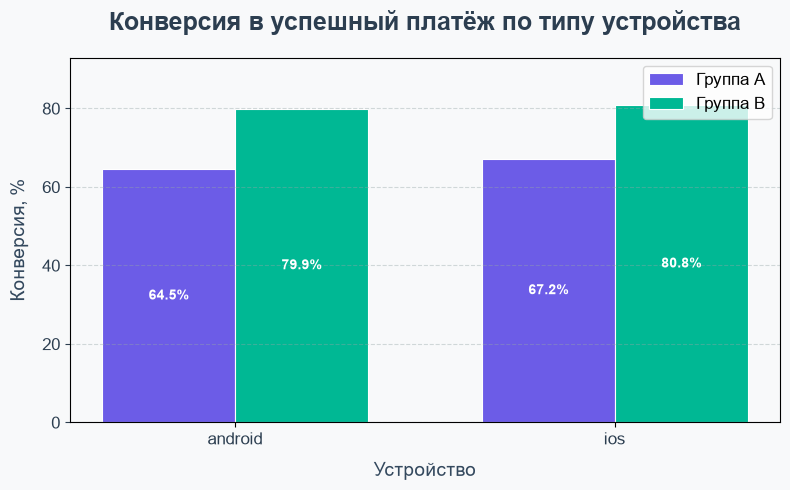

In [47]:
device_plot = device_result.reset_index()
a = device_plot[device_plot['Группа'] == 'A']
b = device_plot[device_plot['Группа'] == 'B']

x = range(len(a))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.set_facecolor('#f8f9fa')
fig.patch.set_facecolor('#f8f9fa')

bars1 = ax.bar(
    [i - width/2 for i in x],
    a['Конверсия'],
    width,
    label='Группа A',
    color='#6C5CE7',
    edgecolor='white',
    linewidth=0.8
)
bars2 = ax.bar(
    [i + width/2 for i in x],
    b['Конверсия'],
    width,
    label='Группа B',
    color='#00B894',
    edgecolor='white',
    linewidth=0.8
)

ax.set_title('Конверсия в успешный платёж по типу устройства',
             fontsize=18, fontweight='bold', pad=20, color='#2c3e50')
ax.set_xlabel('Устройство', fontsize=14, labelpad=10, color='#34495e')
ax.set_ylabel('Конверсия, %', fontsize=14, labelpad=10, color='#34495e')

ax.set_xticks(x)
ax.set_xticklabels(a['Устройство'], ha='center', fontsize=12, color='#2c3e50')
ax.tick_params(axis='y', labelsize=12, colors='#2c3e50')

max_val = max(a['Конверсия'].max(), b['Конверсия'].max())
ax.set_ylim(0, max_val * 1.15)


ax.yaxis.grid(True, linestyle='--', alpha=0.4, color='#95a5a6')
ax.xaxis.grid(False)

legend = ax.legend(
    loc='upper right',
    frameon=True,
    fontsize=12,
    title_fontsize=13
)
legend.get_title().set_color('#2c3e50')

for bars in [bars1, bars2]:
    ax.bar_label(
        bars,
        fmt='%.1f%%',
        label_type='center',
        color='white',
        fontsize=10,
        fontweight='bold',
        padding=0
    )

plt.tight_layout()
plt.show()

In [48]:
city_result = (
    user_segments
    .groupby(['Город', 'Группа'])['Успешный платёж']
    .agg(['sum', 'count'])
    .rename(columns={
        'sum': 'Успешные платежи',
        'count': 'Пользователи'
    })
)

city_result['Конверсия'] = (
    city_result['Успешные платежи'] /
    city_result['Пользователи'] * 100
).round(1)

city_result

Успешные платежи  Пользователи  Конверсия
Город  Группа                                           
Москва A                    181           288       62.8
       B                    248           306       81.0
Регион A                    179           268       66.8
       B                    187           245       76.3
СПб    A                    133           194       68.6
       B                    168           199       84.4

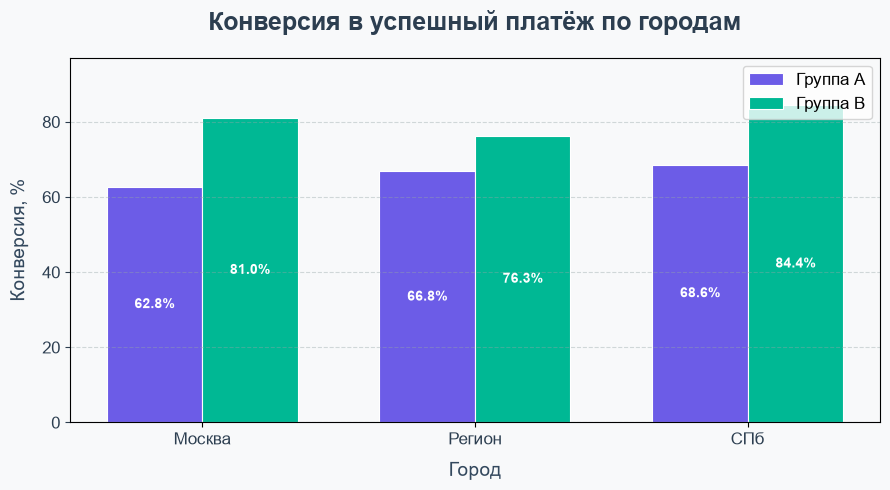

In [49]:
city_plot = city_result.reset_index()
a = city_plot[city_plot['Группа'] == 'A']
b = city_plot[city_plot['Группа'] == 'B']

x = range(len(a))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
ax.set_facecolor('#f8f9fa')
fig.patch.set_facecolor('#f8f9fa')

bars1 = ax.bar(
    [i - width/2 for i in x],
    a['Конверсия'],
    width,
    label='Группа A',
    color='#6C5CE7',
    edgecolor='white',
    linewidth=0.8
)
bars2 = ax.bar(
    [i + width/2 for i in x],
    b['Конверсия'],
    width,
    label='Группа B',
    color='#00B894',
    edgecolor='white',
    linewidth=0.8
)

ax.set_title('Конверсия в успешный платёж по городам',
             fontsize=18, fontweight='bold', pad=20, color='#2c3e50')
ax.set_xlabel('Город', fontsize=14, labelpad=10, color='#34495e')
ax.set_ylabel('Конверсия, %', fontsize=14, labelpad=10, color='#34495e')

ax.set_xticks(x)
ax.set_xticklabels(a['Город'], ha='center', fontsize=12, color='#2c3e50')  # без поворота, по центру
ax.tick_params(axis='y', labelsize=12, colors='#2c3e50')

max_val = max(a['Конверсия'].max(), b['Конверсия'].max())
ax.set_ylim(0, max_val * 1.15)

ax.yaxis.grid(True, linestyle='--', alpha=0.4, color='#95a5a6')
ax.xaxis.grid(False)

legend = ax.legend(
    loc='upper right',
    frameon=True,
    fontsize=12,
    title_fontsize=13
)
legend.get_title().set_color('#2c3e50')

for bars in [bars1, bars2]:
    ax.bar_label(
        bars,
        fmt='%.1f%%',
        label_type='center',
        color='white',
        fontsize=10,
        fontweight='bold',
        padding=0
    )

plt.tight_layout()
plt.show()

### Вывод

В тестовой группе конверсия выше контрольной во всех рассмотренных сегментах.

По устройствам:

- Android: **64,5% → 79,9%**, +15,4 п.п.;
- iOS: **67,2% → 80,8%**, +13,6 п.п.

По городам:

- Москва: +18,2 п.п.;
- Санкт-Петербург: +15,8 п.п.;
- Регионы: +9,5 п.п.

Сегментный анализ показывает, что наблюдаемое увеличение конверсии не ограничивается одним типом устройства или городом.

## 11. Итоговая рекомендация

По результатам A/B-теста новая форма оплаты (группа B) показала статистически значимое улучшение основной метрики — конверсии из открытия формы в успешный платёж.

Конверсия увеличилась с **65,7% до 80,4%**:

- абсолютный прирост — **14,7 п.п.**;
- относительный прирост — **22,3%**;
- 95% ДИ для разницы конверсий — **[10,2%; 19,1%]**;
- p-value < 0,05.

Положительное различие конверсии наблюдается во всех рассмотренных сегментах по типу устройства и городу.

### Рекомендация

Рекомендуется раскатить новую форму оплаты на всех пользователей и продолжить мониторинг конверсии после релиза.